# 1. Import Library 

In [1]:
# pip install matplotlib seaborn requests wordcloud imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import time


# Library untuk NLTK
import nltk

import requests
import csv
from io import StringIO

# Library untuk tokenization
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

# Library untuk filtering atau stopwords removal
from nltk.corpus import stopwords
nltk.download('stopwords')

from wordcloud import WordCloud



# Library untuk stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

#Naive bayes
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE #smote biar seimbang

# logistic regression
from sklearn.linear_model import LogisticRegression

# SVM
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import classification_report
import joblib


warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /Users/irma95/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/irma95/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/irma95/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
pd.set_option('display.max_rows', None)      # tampilkan semua baris
pd.set_option('display.max_columns', None)   # tampilkan semua kolom
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# 2. Load Dataset

In [4]:
path = '../dataset/SP4N LAPOR.csv'
df = pd.read_csv(path)

In [5]:
df.sample(5)

,userName,score,at,content
1251,Pengguna Google,5,2020-02-27 21:15:38,"Install, Buka, Registrasi, Lihat isi interaksi nya.. Knp jadi suka ya... Begitu besar ekspetasi masyarakat pada pemerintah akan pelayanan publik yang profesional dan transparan. Semoga Indonesiaku jaya selalu 💪💪💪"
1610,Pengguna Google,5,2019-09-19 06:50:38,Sukses selalu
741,dsunzilla,1,2021-11-06 08:44:32,"hanya menanggapi laporan yg terverifikasi. padahal udah coba beberapa kali mau verifikasi sampe bikin akun baru, masih aja ga bisa verifikasi."
568,Cahyadi Slamet,1,2022-05-26 11:24:06,"Jelek sekali.. kenapa aplikasi yg dibuat negara kok seperti main2, susah akses, susah login, susah kirim.. seperti hanya terpenuhi kewajiban sudah dibuat saja, tapi nol aplikasinya,"
627,Ayu Widya Srikandi,1,2022-03-13 03:41:43,"Sangat buruk ,"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  1625 non-null   object
 1   score     1625 non-null   int64 
 2   at        1625 non-null   object
 3   content   1625 non-null   object
dtypes: int64(1), object(3)
memory usage: 50.9+ KB


# 3. Data Preparation

mengecek data kosong 

In [7]:
# cek missing value
df.isnull().sum()

userName    0
score       0
at          0
content     0
dtype: int64

Tidak ada data kosong pada dataset 

In [8]:
# cek data duplikat

df.duplicated().sum()

np.int64(0)

Tidak ada data duplicated

In [9]:
df = df.drop(columns=['userName','at'])

Hapus kolom yang tidak di perlukan ada 2 : yaitu kolom userName dan at

In [10]:
df = df.rename(columns={'content':"text"})

ganti nama kolom content menjasi text

In [11]:
df.sample(10)

,score,text
227,1,"Bikin aplikasi yg niat , boro2 mau lapor , masuknya aja muter2 😂 kocak !!!"
44,1,Dasar kalian ini Pemerintah macam apa? Bikin Aplikasi aja gak becus. Pajak minta gede.
993,3,Alasan nya supaya saya bisa buat laporan di daerah saya
499,1,Masih banyak bug
380,1,Lapor tp ujung ujungnya suruh lapor sendiri ke polisi yaa ngapain ada app ini hadeh
786,1,Kenapa ya sering 'internal server error' segera di perbaiki!!
403,5,"Penggunaan Lapor,di balas dan di tanggapin,moga lancar berkelanjutan🙏"
1445,1,"Aneh,, saya membuat laporan, tapi terabaikan,, padahal liat yg lain, langsung diproses,, gmana sih"
1192,1,"Aplikasi tempat lapor tapi kurang tanggapan keluh kesah orang, ngak jelas, mending lapor langsung pada YME"
1546,5,Melaporkan masalah kini lebih cepat trimaksih lapor


# 4. Data Preprocessing

1. Casefolding : fungsi untuk mengubah text menjadi lowercase.

In [12]:
def casefoldingText(text):
    text = str(text).lower()
    return text

2. Cleaning Text : fungsi untuk menghapus mentions, hastag, RT, link, dan numbers dari text.

In [13]:
def cleaningText(text):
    if not isinstance(text, str):  # handle NaN/null
        return ""
    
    text = text.lower()
    
    text = re.sub(r"http\S+", "", text)        # hapus URL
    text = re.sub(r"@\w+", "", text)           # hapus mention
    text = re.sub(r"#\w+", "", text)           # hapus hashtag
    text = re.sub(r"\bRT\b", "", text)         # hapus RT
    text = re.sub(r"\n", " ", text)            # hapus newline    
    text = re.sub(r"[^a-zA-Z\s]", "", text)    # hapus simbol & angka
    
    text = re.sub(r'(.)\1{2,}', r'\1', text)   # huruf berulang (cooool → cool)
    
    text = re.sub(r'\b(wk|wkwk|haha|hehe|hihi)+\b', "", text)  # hapus tawa
    
    text = re.sub(r'\bx+\b', '', text)         # hapus "x"
    
    text = re.sub(r"\s+", " ", text)           # rapikan spasi
    text = text.strip()
    
    return text

3. Normalization : mengubah kata slang/tidak baku menjadi kata baku

In [14]:
slangwords = {
    "ak": "aku",
    "aq": "aku",
    "gw": "saya",
    "gue": "saya",
    "loe": "kamu",
    "km": "kamu",
    "tdk": "tidak",
    "gk": "tidak",
    "ga": "tidak",
    "ngga": "tidak",
    "bgt": "banget",
    "bgtt": "banget",
    "bngt": "banget",
    "ngak" : "tidak",
    "gak" : "tidak",
    "Beramnfaat" : "bermanfaat",
    "gbr": "gambar",
    "hrs" : "harus",
    "eror" : "error",
    "app" : "aplikasi",
    "boro" : "tidak-samasekali",
    "lporan" : "laporan",
    "lemot" : "lambat",
    "apk" : "aplikasi",
    "aq" : "saya",
    "q" : "saya",
    "rekrut" : "mempekerjakan",
    "ato" : "atau",
    "abal2" : "palsu",
    "Hoax" : "palsu",
    "sdh" : "sudah",
    "Applikasi" : "aplikasi",
    "jls" : "jelas",
    "manteman" : "teman-teman",
    "bersein" : "benahi",
    "benahin" : "benahi",
    "dibersihin" : "benahi",
    "sory" : "maaf",
    "wacana" : "gagasan",
    "cm" : "cuma",
    "qta" : "kita",
    "gmn" : "bagaimana",
    "untungin" : "untung",
    "pny" : "punya",
    "yg" : "yang",
    "doang" : "saja",
    "masi" : "masih",
    "ror" : "error",
    "utk" : "untuk",
    "stelah" : "setelah",
    "gx" : "tidak",
    "dak" : "tidak",
    "ndak" : "tidak",
    "tiba2" : "tiba-tiba",
    "applikasi": "aplikasi",
    "amplikasi":"aplikasi",
    "tpi":"tapi",
    "web":"website",
    "aduan":"pengaduan",
    "ngabisin":"habiskan",
    "review":"ulasan",
    "pentingseolah": "penting seolah",
    "seolah" : "cuma",
    "lapor":"laporan",
    "klean":"kalian",
    "via":"lewat",
    "ni":"ini",
    "ga usah":"tidak-usah",
    "tpsaat":"tapi saat",
    "passwird":"password",
    "aplikasynya":"aplikasi saya",
    "tidaklanjuti":"tindak-lanjuti",
    "gede":"besar",
    "ngefek": "perubahan",
    "g" : "tidak",
    "tau": "tahu",
    "bsa": "bisa",
    "trs":"terus",
    "bobrok":"gagal",
    "kocak": "lucu",
    "unmon":"tidak modifikasi",
    "perundangundangan":"undang undang",
    "lelet":"lambat",   
    "ntah":"tidak tahu",
    "unfaedah":"tidak bermanfaat",
    "php":"pemberi harapan palsu",
    "applikasinya":"aplikasi",
    "ajb":"akta jual beli",
    "jtaan":"jutaan",
    "burik":"jelek",
    "pw":"password",
    "gunadaftar":"guna daftar",
    "bisaerro":"bisa error",
    "haris":"harus",
    "ganiat":"tidak niat",
    "siakarena":"sia-sia karena"
}

# stopword JAKI, 

In [15]:
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

4. Tokenizing Text : fungsi untuk memecah text menjadi list tokens.

In [16]:
def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

5. Stopword Removal : fungsi untuk menghapus stopwords dalam bahasa Indonesia ataupun Inggris.

In [17]:


def remove_stopwords(text):  # Remove stopwords in a text
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)

    listStopwords.update([
        'iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah",
        "woi","woii","woy","jobstreet","linkedin","glints","kalibrr","indeed",
        'pt','perusahaan','cv','tbk',"semua","sama","sekarang","lagi","mungkin",
        "tenang","saja","masih","akan","haduhh","lucu","wkwkwkwk",
        "jobsteet","asw","asyudahlah","lina", "JAKI","asu","eh","nih",
        "wkwk','wkwkwk','wkwkwkwk','wk','wkk','wkw','wkwwk"
    ])


    listStopwords.discard("terimakasih")
    listStopwords.discard("dapat")
    listStopwords.discard("mendapatkan")
    listStopwords.discard("kasih")
    listStopwords.discard("tidak")
    listStopwords.discard("saya")
    listStopwords.discard("kami")
    listStopwords.discard("kalian")
    listStopwords.discard("baik")
    listStopwords.discard("bagus")
    listStopwords.discard("bisa")
    listStopwords.discard("bantu")
    listStopwords.discard("jawab")
    listStopwords.discard("ada")
    listStopwords.discard("baru")
    listStopwords.discard("pertama")
    listStopwords.discard("melihat")
    listStopwords.discard("laporan")
    listStopwords.discard("lama")
    listStopwords.discard("tanpa")
    listStopwords.discard("tindak")
    listStopwords.discard("jelas")
   

# jangan hapus kata seperti:
# bisa, jawab, bantu, dll


    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)

    return filtered


6. Stemming : fungsi untuk mengubah text menjadi bentuk dasar. Namun pada proyek ini tidak akan digunakan karena proses nya yang lama.

In [18]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmingText(tokens):
    return [stemmer.stem(word) for word in tokens]

7. toSentence

In [19]:
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

copy dataframe asli (df) menjadi df_clean : artinya data yang sudah di bersihkan di tahap preparation sebelumnya

In [20]:
df_old = df.copy()

In [21]:
df_old.sample(5)

,score,text
1418,5,LAPOR TOP APALAGI BISA BANTU SAYA DALAM MENANGGULANGI NOTARIS WIRANTO SUWONGSO SH CIDENG TIMUR 75 A-B JAKARTA PUSAT
83,1,Aplikasi error
1319,5,Good
12,1,Aplikasi yang memakan banyak anggaran tapi saya buat laporan dilihat pun tidak langsung diarsipkan. Bukan sebuah solusi!!!
542,1,Aplikasi span lapor elor terus tiap hari percuma pemerintah mengadakan aplikasi ini klw aplikasi span lapor ga bisa di gunakan


In [22]:
df_clean = df.copy()

In [23]:
# mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'casefolding_text'
df_clean['casefolding_text'] = df_clean['text'].apply(casefoldingText)

# membersihkan teks dan menyimpan ya di kolom 'clean_content'
df_clean['cleaning_text'] = df_clean['casefolding_text'].apply(cleaningText)

# mengganti kata-kata slang/tidak baku menjadi kata baku
df_clean['slangword_text'] = df_clean['cleaning_text'].apply(fix_slangwords)

# memecah teks menjadi token (kata-kata) dan menyimpanya di 'tokenizing_text'
df_clean['tokenizing_text'] = df_clean['slangword_text'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'stopword_text'
df_clean['stopword_text'] = df_clean['tokenizing_text'].apply(remove_stopwords)

# menggunakan stemming untuk kata dasar'
# df_clean['stemming_text'] = df_clean['stopword_text'].apply(stemmingText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'final_text'
df_clean['final_text'] = df_clean['stopword_text'].apply(toSentence)

In [24]:
df_clean.columns

Index(['score', 'text', 'casefolding_text', 'cleaning_text', 'slangword_text',
       'tokenizing_text', 'stopword_text', 'final_text'],
      dtype='object')

In [25]:
df_clean.sample(5)

,score,text,casefolding_text,cleaning_text,slangword_text,tokenizing_text,stopword_text,final_text
650,2,"Kenapa aplikasi lapor ku server eror trs, tdk bisa buat mengirim laporan, , 2 bintang dulu kalo saya sudah bisa mengirim laporan baru aku tambahin, terimakasih","kenapa aplikasi lapor ku server eror trs, tdk bisa buat mengirim laporan, , 2 bintang dulu kalo saya sudah bisa mengirim laporan baru aku tambahin, terimakasih",kenapa aplikasi lapor ku server eror trs tdk bisa buat mengirim laporan bintang dulu kalo saya sudah bisa mengirim laporan baru aku tambahin terimakasih,kenapa aplikasi laporan ku server error terus tidak bisa buat mengirim laporan bintang dulu kalo saya sudah bisa mengirim laporan baru aku tambahin terimakasih,"[kenapa, aplikasi, laporan, ku, server, error, terus, tidak, bisa, buat, mengirim, laporan, bintang, dulu, kalo, saya, sudah, bisa, mengirim, laporan, baru, aku, tambahin, terimakasih]","[aplikasi, laporan, server, error, tidak, bisa, mengirim, laporan, bintang, kalo, saya, bisa, mengirim, laporan, baru, tambahin, terimakasih]",aplikasi laporan server error tidak bisa mengirim laporan bintang kalo saya bisa mengirim laporan baru tambahin terimakasih
425,1,Mengecewakan,mengecewakan,mengecewakan,mengecewakan,[mengecewakan],[mengecewakan],mengecewakan
1046,5,"Semoga sukses dan lebih profesional lagi,,,,amiiin YRA","semoga sukses dan lebih profesional lagi,,,,amiiin yra",semoga sukses dan lebih profesional lagiamin yra,semoga sukses dan lebih profesional lagiamin yra,"[semoga, sukses, dan, lebih, profesional, lagiamin, yra]","[semoga, sukses, profesional, lagiamin, yra]",semoga sukses profesional lagiamin yra
1343,5,Keren,keren,keren,keren,[keren],[keren],keren
679,1,"sering bermasalah, tidak bisa posting laporan","sering bermasalah, tidak bisa posting laporan",sering bermasalah tidak bisa posting laporan,sering bermasalah tidak bisa posting laporan,"[sering, bermasalah, tidak, bisa, posting, laporan]","[bermasalah, tidak, bisa, posting, laporan]",bermasalah tidak bisa posting laporan


In [26]:
df_clean.iloc[953]

score                                                            2
text                      Applikasi baik bisa jawab keluhan rakyat
casefolding_text          applikasi baik bisa jawab keluhan rakyat
cleaning_text             applikasi baik bisa jawab keluhan rakyat
slangword_text             aplikasi baik bisa jawab keluhan rakyat
tokenizing_text     [aplikasi, baik, bisa, jawab, keluhan, rakyat]
stopword_text       [aplikasi, baik, bisa, jawab, keluhan, rakyat]
final_text                 aplikasi baik bisa jawab keluhan rakyat
Name: 953, dtype: object

# 5. Pelabelan

Mendefinisikan fungsi untuk menghitung polaritas sentimen.

In [27]:
def label_sentimen(score):
    if score <= 2:
        return "negatif"
    elif score == 3:
        return "netral"
    else:
        return "positif"

In [28]:
# apply fungsi
df_clean['label'] = df_clean['score'].apply(label_sentimen)

In [29]:
df_clean.sample(3)

,score,text,casefolding_text,cleaning_text,slangword_text,tokenizing_text,stopword_text,final_text,label
677,5,Terima kasih dg adanya lapor sangat membantu masyarakat,terima kasih dg adanya lapor sangat membantu masyarakat,terima kasih dg adanya lapor sangat membantu masyarakat,terima kasih dg adanya laporan sangat membantu masyarakat,"[terima, kasih, dg, adanya, laporan, sangat, membantu, masyarakat]","[terima, kasih, dg, laporan, membantu, masyarakat]",terima kasih dg laporan membantu masyarakat,positif
1590,5,Aplikasinya menarik,aplikasinya menarik,aplikasinya menarik,aplikasinya menarik,"[aplikasinya, menarik]","[aplikasinya, menarik]",aplikasinya menarik,positif
1451,5,Aplikasi yang bagus. Tapi mohon tingkatkan lagi kecepatan dari tindak lanjut laporannya ya....,aplikasi yang bagus. tapi mohon tingkatkan lagi kecepatan dari tindak lanjut laporannya ya....,aplikasi yang bagus tapi mohon tingkatkan lagi kecepatan dari tindak lanjut laporannya ya,aplikasi yang bagus tapi mohon tingkatkan lagi kecepatan dari tindak lanjut laporannya ya,"[aplikasi, yang, bagus, tapi, mohon, tingkatkan, lagi, kecepatan, dari, tindak, lanjut, laporannya, ya]","[aplikasi, bagus, mohon, tingkatkan, kecepatan, tindak, laporannya]",aplikasi bagus mohon tingkatkan kecepatan tindak laporannya,positif


In [30]:
df_clean.iloc[917]

score                                                                                 1
text                                    Ga ngefek, beberapa kali ku lapor ga ada respon
casefolding_text                        ga ngefek, beberapa kali ku lapor ga ada respon
cleaning_text                            ga ngefek beberapa kali ku lapor ga ada respon
slangword_text                tidak perubahan beberapa kali ku laporan tidak ada respon
tokenizing_text     [tidak, perubahan, beberapa, kali, ku, laporan, tidak, ada, respon]
stopword_text                     [tidak, perubahan, kali, laporan, tidak, ada, respon]
final_text                                tidak perubahan kali laporan tidak ada respon
label                                                                           negatif
Name: 917, dtype: object

In [31]:
# menghitung jumlah masing-masing label positive,neutral,negatif berdasarkan score
df_clean['label'].value_counts()

label
negatif    831
positif    688
netral     106
Name: count, dtype: int64

# 6. EDA ( Exploratory Data Analysis )

Menampilkan distribusi Sentimen dengan histogram.

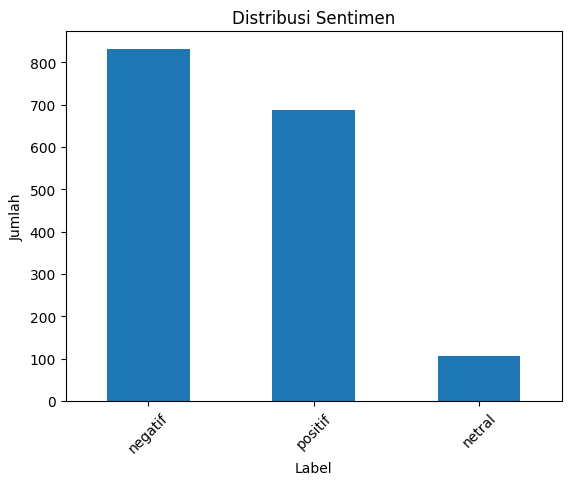

In [32]:
# Visualisasi dengan Bar Chart
df_clean['label'].value_counts().plot(kind='bar')

plt.title('Distribusi Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')

plt.xticks(rotation=45)  # 🔥 ini yang benar

plt.show()

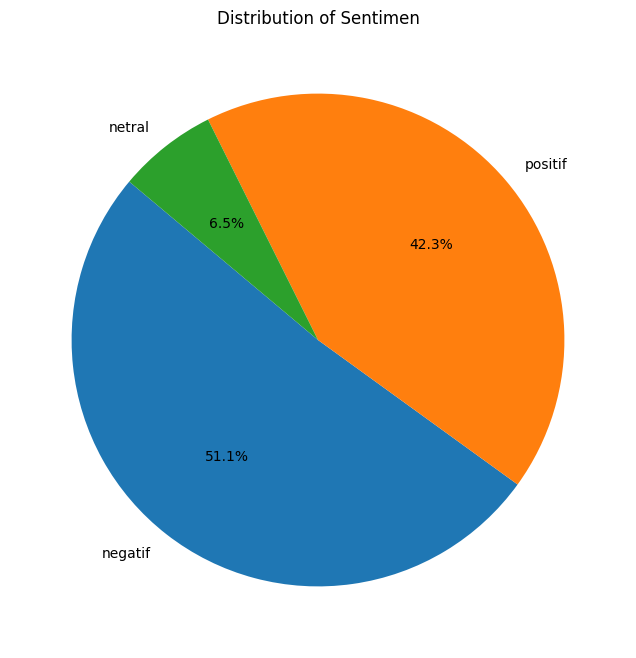

In [ ]:

label_counts = df_clean['label'].value_counts()

# Menampilkan diagram lingkaran
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Sentimen')
plt.show()

Berdasarkan hasil visualisasi distribusi sentimen, terlihat bahwa data didominasi oleh sentimen negatif dengan jumlah <b><span style="color:yellow"> 831</span></b> data, diikuti oleh sentimen positif sebanyak <b><span style="color:yellow">688</b></span> data, dan sentimen netral sebanyak <b><span style="color:yellow">106</b></span> data. Hal ini menunjukkan bahwa mayoritas pengguna cenderung memberikan ulasan dengan kecenderungan negatif. Selain itu, proporsi sentimen netral yang relatif kecil mengindikasikan bahwa sebagian besar pengguna memiliki opini yang jelas, baik positif maupun negatif, terhadap objek yang diteliti.

Word Cloud Umum

Membuat wordcloud dari dataset tanpa melihat label.

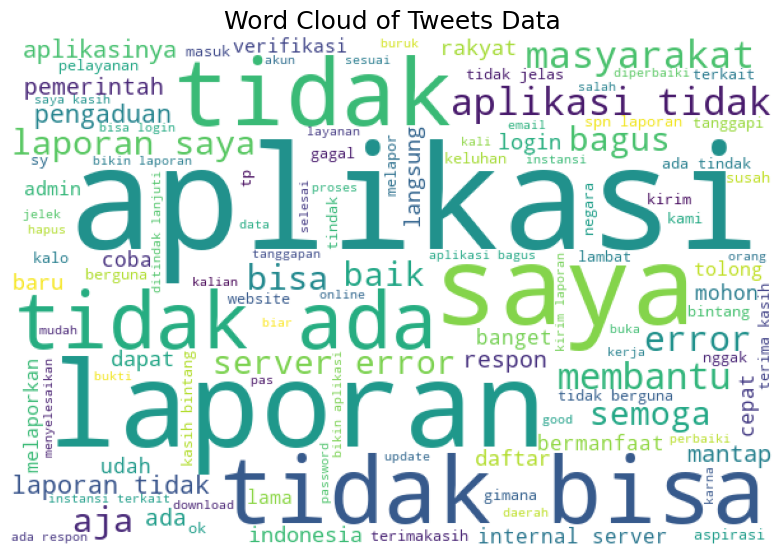

In [34]:
# Membuat wordcloud secara umum

list_words = ''

for tweet in df_clean['stopword_text']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Tweets Data', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

Word Cloud Positive

In [35]:
# filter data positif
positive_tweets = df_clean[df_clean['label'] == 'positif']

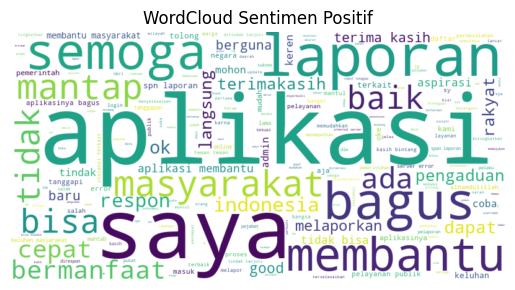

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(positive_tweets['final_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Sentimen Positif')
plt.show()

Word Cloud Negatif

In [37]:
negative_tweets = df_clean[df_clean['label'] == 'negatif']

In [38]:
text_negatif = ' '.join(negative_tweets['final_text'])

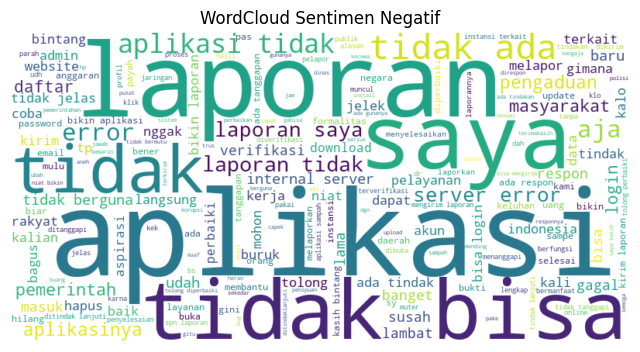

In [39]:
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_negatif)

plt.figure(figsize=(8,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Sentimen Negatif')

plt.show()

Word Cloud Neutral

In [40]:
neutral_tweets = df_clean[df_clean['label'] == 'netral']

In [41]:
text_netral = ' '.join(neutral_tweets['final_text'])

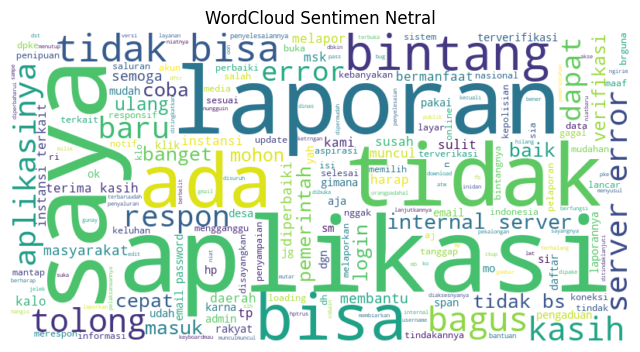

In [42]:

wordcloud_netral = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_netral)

plt.figure(figsize=(8,5))
plt.imshow(wordcloud_netral, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Sentimen Netral')

plt.show()

<b><span style="color:lightblue">Visualisasi dataset</b></span>

Menampilkan distribusi dari panjang text.

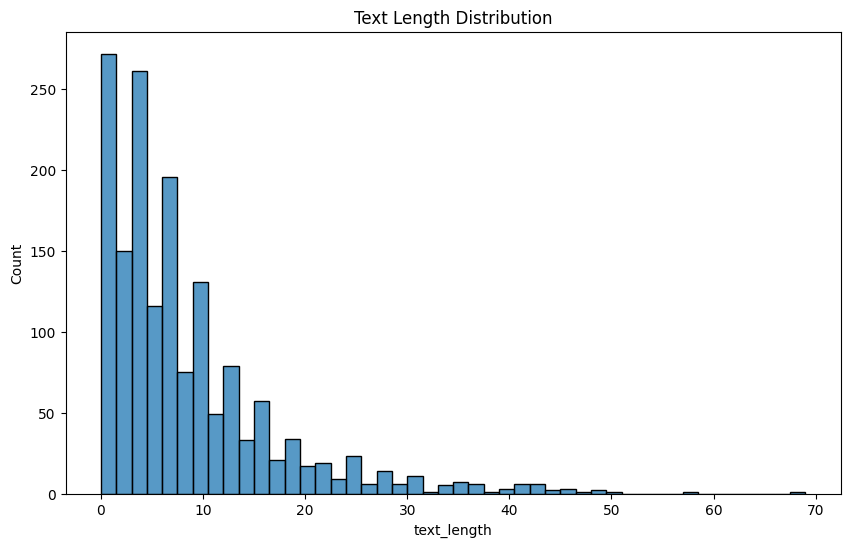

In [43]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
df_clean['text_length'] = df_clean['final_text'].apply(lambda x: len(x.split()))
sns.histplot(df_clean['text_length'])
plt.title('Text Length Distribution')
plt.show()

Histogram distribusi panjang teks menunjukkan bahwa sebagian besar data memiliki panjang 1–10 kata. Distribusi bersifat right-skewed, di mana jumlah teks menurun seiring bertambahnya panjang teks. Hal ini mengindikasikan bahwa pengguna cenderung memberikan ulasan singkat.

<b><span style="color:lightblue">Menampilkan kata yang paling sering muncul.</span></b>

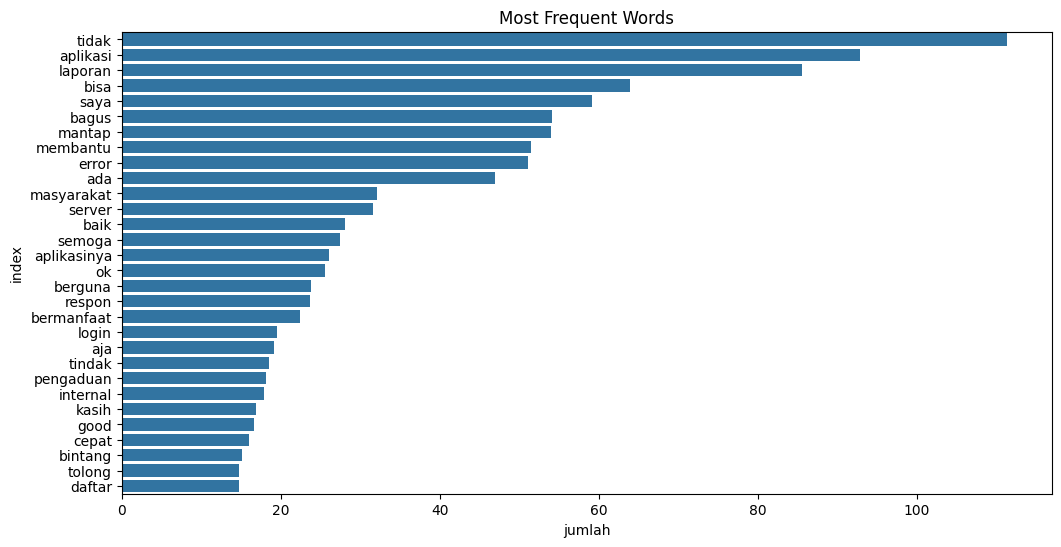

In [44]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_clean['final_text'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(30)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

In [45]:
# simpan df_clean ke csv
df_clean.to_csv("../dataset/df_clean.csv", index=False)

# 7. Feature Extraction

Mengubah teks jadi angka ( supaya bisa dibaca model)

In [46]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df_clean['final_text'])
y = df_clean['label']


In [47]:
# Save tfidf 
joblib.dump(tfidf, '../save_model/tfidf.pkl')

['../save_model/tfidf.pkl']

# 8. Splitting Data

In [48]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 9. Modeling (Training)

In [49]:
# Tambahkan SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)  # k_neighbors kecil karena netral sedikit

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi sebelum SMOTE:")
print(y_train.value_counts())

print("\nDistribusi setelah SMOTE:")
print(pd.Series(y_train_res).value_counts())


Distribusi sebelum SMOTE:
label
negatif    662
positif    553
netral      85
Name: count, dtype: int64

Distribusi setelah SMOTE:
label
negatif    662
positif    662
netral     662
Name: count, dtype: int64


In [50]:
# Training Model

model_nb = MultinomialNB()
model_nb.fit(X_train_res, y_train_res)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [51]:
# 6. Prediksi

y_pred_nb = model_nb.predict(X_test)


In [52]:
# akurasi

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy Naive Bayes :", accuracy_nb)

# detail evaluasi
print("\nClassification Report: Naive Bayes \n")
print(classification_report(y_test, y_pred_nb))

Accuracy Naive Bayes : 0.7630769230769231

Classification Report: Naive Bayes 

              precision    recall  f1-score   support

     negatif       0.81      0.84      0.82       169
      netral       0.11      0.19      0.14        21
     positif       0.90      0.76      0.82       135

    accuracy                           0.76       325
   macro avg       0.61      0.60      0.60       325
weighted avg       0.80      0.76      0.78       325



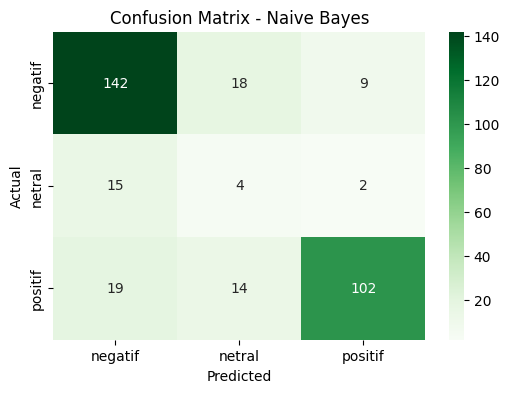

In [53]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,4))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negatif','netral','positif'],
            yticklabels=['negatif','netral','positif'])

plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [54]:
# model logistic regression

model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [55]:
# Prediksi logistic regression

y_pred_lr = model_lr.predict(X_test)

In [56]:
# akurasi
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy Logistic Regression : ", accuracy_lr)

# evaluasi
print("\nClassification Report: Logistic Regression\n")
print(classification_report(y_test, y_pred_lr))


Accuracy Logistic Regression :  0.803076923076923

Classification Report: Logistic Regression

              precision    recall  f1-score   support

     negatif       0.83      0.85      0.84       169
      netral       0.22      0.19      0.21        21
     positif       0.85      0.84      0.84       135

    accuracy                           0.80       325
   macro avg       0.63      0.63      0.63       325
weighted avg       0.80      0.80      0.80       325



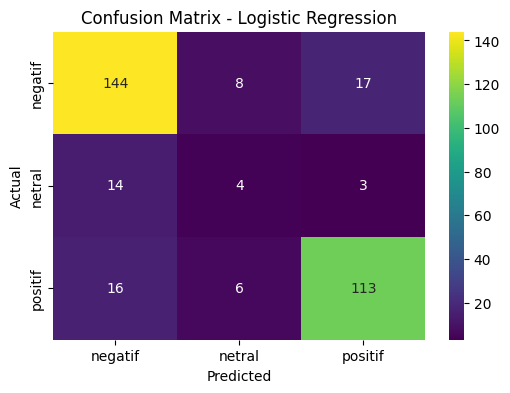

In [57]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='viridis',
            xticklabels=['negatif','netral','positif'],
            yticklabels=['negatif','netral','positif'])

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [58]:
# model SVM

model_svm = LinearSVC(class_weight='balanced')

model_svm.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [59]:
# prediksi
y_pred_svm = model_svm.predict(X_test)

In [60]:
# akurasi
accuracy_svm= accuracy_score(y_test, y_pred_svm)
print("Accuracy SVM :", accuracy_svm)

# evaluasi
print("\nClassification Report: SVM\n")
print(classification_report(y_test, y_pred_svm))


Accuracy SVM : 0.8123076923076923

Classification Report: SVM

              precision    recall  f1-score   support

     negatif       0.82      0.87      0.84       169
      netral       0.18      0.10      0.12        21
     positif       0.86      0.85      0.86       135

    accuracy                           0.81       325
   macro avg       0.62      0.61      0.61       325
weighted avg       0.79      0.81      0.80       325



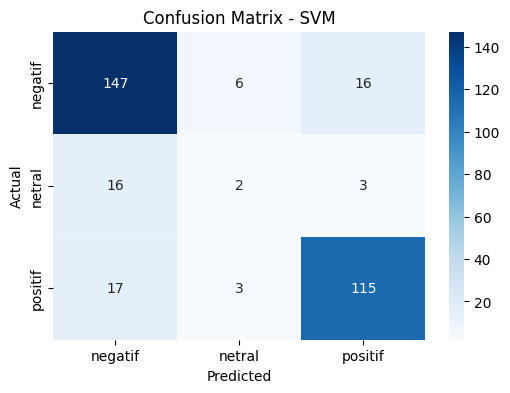

In [61]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negatif','netral','positif'],
            yticklabels=['negatif','netral','positif'])

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [62]:
# coba Hyperparameter Tuning

param_grid = {
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'loss': ['hinge', 'squared_hinge'],
    'dual': [True, False]
}

In [63]:
grid = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1_macro'
)

grid.fit(X_train, y_train)

,estimator,LinearSVC(cla...ht='balanced')
,param_grid,"{'C': [0.01, 0.1, ...], 'dual': [True, False], 'loss': ['hinge', 'squared_hinge']}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [64]:
print("Best parameter:", grid.best_params_)

Best parameter: {'C': 0.1, 'dual': True, 'loss': 'hinge'}


In [65]:
model_svm_tuned = LinearSVC(
    C=grid.best_params_['C'],
    class_weight='balanced',
)

model_svm_tuned.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [66]:
# save model SVM yang sudah di Hyperparameter Tuning
joblib.dump(model_svm_tuned, '../save_model/model_svm_tuned.pkl')

['../save_model/model_svm_tuned.pkl']

In [67]:
y_pred_svm_tuned = model_svm_tuned.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy setelah tuning:",
      accuracy_score(y_test, y_pred_svm_tuned))

print(classification_report(y_test, y_pred_svm_tuned))

Accuracy setelah tuning: 0.8153846153846154
              precision    recall  f1-score   support

     negatif       0.80      0.89      0.84       169
      netral       0.29      0.10      0.14        21
     positif       0.87      0.83      0.85       135

    accuracy                           0.82       325
   macro avg       0.65      0.61      0.61       325
weighted avg       0.79      0.82      0.80       325



In [69]:
print("\n=== PERBANDINGAN MODEL ===")
print(f"Naive Bayes        : {accuracy_nb:.3f}")
print(f"Logistic Regression: {accuracy_lr:.3f}")
print(f"SVM                : {accuracy_svm:.3f}")
print("\n=== SVM SETELAH TUNING ===")
accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)

print("Accuracy setelah tuning:", accuracy_svm_tuned)
print(f"SVM (tuned)         : {accuracy_svm_tuned:.3f}")


=== PERBANDINGAN MODEL ===
Naive Bayes        : 0.763
Logistic Regression: 0.803
SVM                : 0.812

=== SVM SETELAH TUNING ===
Accuracy setelah tuning: 0.8153846153846154
SVM (tuned)         : 0.815


# 10. Evaluation Model

In [70]:
df_clean.sample(3)

,score,text,casefolding_text,cleaning_text,slangword_text,tokenizing_text,stopword_text,final_text,label,text_length
744,1,"Pelayanan buruk sekali kita sebagai rakya t itu kalo ada apa apa langsung cepet langsung di tanggapi jangan kalo ada duit nya doang baru cepet, buat apa ada aplikasi pengaduan kalo bikin pengaduan aja tanggepan nya lama sekali saya bikin laporan dari tanggal 17 Oktober 2021 dan sampai 4 November 2021 belom di respon sama sekali, klo tidak ada covid saya Dateng langsung kekelurahan ataupun itu ini kan lagi covid harus nya segala sesuatu itu harus dipercepat bukan diperlambat!!!!!","pelayanan buruk sekali kita sebagai rakya t itu kalo ada apa apa langsung cepet langsung di tanggapi jangan kalo ada duit nya doang baru cepet, buat apa ada aplikasi pengaduan kalo bikin pengaduan aja tanggepan nya lama sekali saya bikin laporan dari tanggal 17 oktober 2021 dan sampai 4 november 2021 belom di respon sama sekali, klo tidak ada covid saya dateng langsung kekelurahan ataupun itu ini kan lagi covid harus nya segala sesuatu itu harus dipercepat bukan diperlambat!!!!!",pelayanan buruk sekali kita sebagai rakya t itu kalo ada apa apa langsung cepet langsung di tanggapi jangan kalo ada duit nya doang baru cepet buat apa ada aplikasi pengaduan kalo bikin pengaduan aja tanggepan nya lama sekali saya bikin laporan dari tanggal oktober dan sampai november belom di respon sama sekali klo tidak ada covid saya dateng langsung kekelurahan ataupun itu ini kan lagi covid harus nya segala sesuatu itu harus dipercepat bukan diperlambat,pelayanan buruk sekali kita sebagai rakya t itu kalo ada apa apa langsung cepet langsung di tanggapi jangan kalo ada duit nya saja baru cepet buat apa ada aplikasi pengaduan kalo bikin pengaduan aja tanggepan nya lama sekali saya bikin laporan dari tanggal oktober dan sampai november belom di respon sama sekali klo tidak ada covid saya dateng langsung kekelurahan ataupun itu ini kan lagi covid harus nya segala sesuatu itu harus dipercepat bukan diperlambat,"[pelayanan, buruk, sekali, kita, sebagai, rakya, t, itu, kalo, ada, apa, apa, langsung, cepet, langsung, di, tanggapi, jangan, kalo, ada, duit, nya, saja, baru, cepet, buat, apa, ada, aplikasi, pengaduan, kalo, bikin, pengaduan, aja, tanggepan, nya, lama, sekali, saya, bikin, laporan, dari, tanggal, oktober, dan, sampai, november, belom, di, respon, sama, sekali, klo, tidak, ada, covid, saya, dateng, langsung, kekelurahan, ataupun, itu, ini, kan, lagi, covid, harus, nya, segala, sesuatu, itu, harus, dipercepat, bukan, diperlambat]","[pelayanan, buruk, rakya, kalo, ada, langsung, cepet, langsung, tanggapi, kalo, ada, duit, baru, cepet, ada, aplikasi, pengaduan, kalo, bikin, pengaduan, aja, tanggepan, lama, saya, bikin, laporan, tanggal, oktober, november, belom, respon, klo, tidak, ada, covid, saya, dateng, langsung, kekelurahan, covid, dipercepat, diperlambat]",pelayanan buruk rakya kalo ada langsung cepet langsung tanggapi kalo ada duit baru cepet ada aplikasi pengaduan kalo bikin pengaduan aja tanggepan lama saya bikin laporan tanggal oktober november belom respon klo tidak ada covid saya dateng langsung kekelurahan covid dipercepat diperlambat,negatif,42
751,1,Sarana pelaporan tidak berguna. Kirim Laporan tidak bisa (gagal) dengan keterangan 'Internal Server Error: Server Error',sarana pelaporan tidak berguna. kirim laporan tidak bisa (gagal) dengan keterangan 'internal server error: server error',sarana pelaporan tidak berguna kirim laporan tidak bisa gagal dengan keterangan internal server error server error,sarana pelaporan tidak berguna kirim laporan tidak bisa gagal dengan keterangan internal server error server error,"[sarana, pelaporan, tidak, berguna, kirim, laporan, tidak, bisa, gagal, dengan, keterangan, internal, server, error, server, error]","[sarana, pelaporan, tidak, berguna, kirim, laporan, tidak, bisa, gagal, keterangan, internal, server, error, server, error]",sarana pelaporan tidak berguna kirim laporan tidak bisa gagal keter

In [71]:
df_clean.iloc[10]

score                                                                                                                                             2
text                               aplikasi sering lemot. Untuk kirim pengaduan saja sering muncul masalah. Tak seperti di platform non pemerintah.
casefolding_text                   aplikasi sering lemot. untuk kirim pengaduan saja sering muncul masalah. tak seperti di platform non pemerintah.
cleaning_text                         aplikasi sering lemot untuk kirim pengaduan saja sering muncul masalah tak seperti di platform non pemerintah
slangword_text                       aplikasi sering lambat untuk kirim pengaduan saja sering muncul masalah tak seperti di platform non pemerintah
tokenizing_text     [aplikasi, sering, lambat, untuk, kirim, pengaduan, saja, sering, muncul, masalah, tak, seperti, di, platform, non, pemerintah]
stopword_text                                                               [aplikasi, lambat, kirim, pengaduan,

In [72]:
evaluasi_text = df_clean['final_text'].iloc[732]

print("Kalimat:", evaluasi_text)

Kalimat: aplikasi tidak jelas


In [73]:
text_tfidf = tfidf.transform([evaluasi_text])

In [74]:
evaluasi_pred = model_svm_tuned.predict(text_tfidf)
print("Prediksi sentimen:", evaluasi_pred[0])


Prediksi sentimen: negatif
